<a href="https://colab.research.google.com/github/fox5711n/-Projeto-Redes-de-Computadores-com-Cisco-Packet-Tracer/blob/codex/previsao_vendas_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# istema de Previsão de Vendas
### Análise Histórica 2023-2024 + Projeção 90 dias com Prophet

**Produtos analisados:** Notebook · Smartphone · Monitor · Cadeira Gamer  
**Banco de dados:** SQLite (equivalente ao MySQL original)  
**Modelo de previsão:** Meta Prophet (IA)

---
> ▶Execute as células **em ordem**, de cima para baixo.

## Célula 1 — Instalar bibliotecas

In [1]:
!pip install prophet --quiet
!pip install pandas matplotlib --quiet
print('Bibliotecas instaladas com sucesso!')

Bibliotecas instaladas com sucesso!


## Célula 2 — Criar banco SQLite + popular com dados

In [2]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import date, timedelta
import random

DB_PATH = 'vendas.db'

def criar_conexao():
    return sqlite3.connect(DB_PATH)

def fechar_conexao(conn):
    conn.close()

conn = criar_conexao()
cursor = conn.cursor()

cursor.executescript("""
    CREATE TABLE IF NOT EXISTS categorias (
        id   INTEGER PRIMARY KEY AUTOINCREMENT,
        nome TEXT NOT NULL UNIQUE
    );
    CREATE TABLE IF NOT EXISTS produtos (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        nome         TEXT    NOT NULL,
        preco_unit   REAL    NOT NULL,
        categoria_id INTEGER,
        FOREIGN KEY (categoria_id) REFERENCES categorias(id)
    );
    CREATE TABLE IF NOT EXISTS vendas (
        id          INTEGER PRIMARY KEY AUTOINCREMENT,
        produto_id  INTEGER NOT NULL,
        data_venda  TEXT    NOT NULL,
        quantidade  INTEGER NOT NULL,
        receita     REAL    NOT NULL,
        FOREIGN KEY (produto_id) REFERENCES produtos(id)
    );
""")
conn.commit()

categorias = [('Eletrônicos',), ('Móveis',)]
cursor.executemany('INSERT OR IGNORE INTO categorias (nome) VALUES (?)', categorias)
cursor.execute('SELECT id FROM categorias WHERE nome="Eletrônicos"')
id_elet = cursor.fetchone()[0]
cursor.execute('SELECT id FROM categorias WHERE nome="Móveis"')
id_mov  = cursor.fetchone()[0]

produtos_data = [
    ('Notebook',      3500.0, id_elet),
    ('Smartphone',    2000.0, id_elet),
    ('Monitor',       1500.0, id_elet),
    ('Cadeira Gamer', 1200.0, id_mov),
]
cursor.executemany(
    'INSERT OR IGNORE INTO produtos (nome, preco_unit, categoria_id) VALUES (?,?,?)',
    produtos_data)
conn.commit()

random.seed(42)
np.random.seed(42)

cursor.execute('SELECT COUNT(*) FROM vendas')
if cursor.fetchone()[0] == 0:
    cursor.execute('SELECT id, nome, preco_unit FROM produtos')
    lista = cursor.fetchall()
    inicio = date(2023, 1, 1)
    fim    = date(2024, 12, 31)
    delta  = (fim - inicio).days
    perfis = {
        'Notebook':      {'base': 8,  'std': 3, 'pico': [11,12], 'mult': 2.2},
        'Smartphone':    {'base': 6,  'std': 2, 'pico': [11,12], 'mult': 1.8},
        'Monitor':       {'base': 7,  'std': 2, 'pico': [11,12], 'mult': 2.0},
        'Cadeira Gamer': {'base': 7,  'std': 2, 'pico': [11,12], 'mult': 1.9},
    }
    registros = []
    for pid, nome, preco in lista:
        p = perfis[nome]
        for i in range(delta + 1):
            d   = inicio + timedelta(days=i)
            m   = p['mult'] if d.month in p['pico'] else 1.0
            tr  = 1.0 + 0.0003 * i
            qtd = max(1, int(np.random.normal(p['base'] * m * tr, p['std'])))
            rec = round(qtd * preco, 2)
            registros.append((pid, d.isoformat(), qtd, rec))
    cursor.executemany(
        'INSERT INTO vendas (produto_id, data_venda, quantidade, receita) VALUES (?,?,?,?)',
        registros)
    conn.commit()
    print(f'{len(registros):,} registros inseridos no banco.')
else:
    print('Banco já populado.')

fechar_conexao(conn)

conn = criar_conexao()
df_check = pd.read_sql("""
    SELECT p.nome, COUNT(*) AS dias, ROUND(SUM(v.receita),0) AS receita_total
    FROM vendas v JOIN produtos p ON p.id = v.produto_id
    GROUP BY p.nome
""", conn)
fechar_conexao(conn)
df_check['receita_total'] = df_check['receita_total'].map('R$ {:,.0f}'.format)
print("\n📦 Resumo do banco:")
print(df_check.to_string(index=False))

2,924 registros inseridos no banco.

📦 Resumo do banco:
         nome  dias receita_total
Cadeira Gamer   731  R$ 7,479,600
      Monitor   731  R$ 9,505,500
     Notebook   731 R$ 26,047,000
   Smartphone   731 R$ 10,662,000


## Célula 3 — Gráfico de previsão por produto

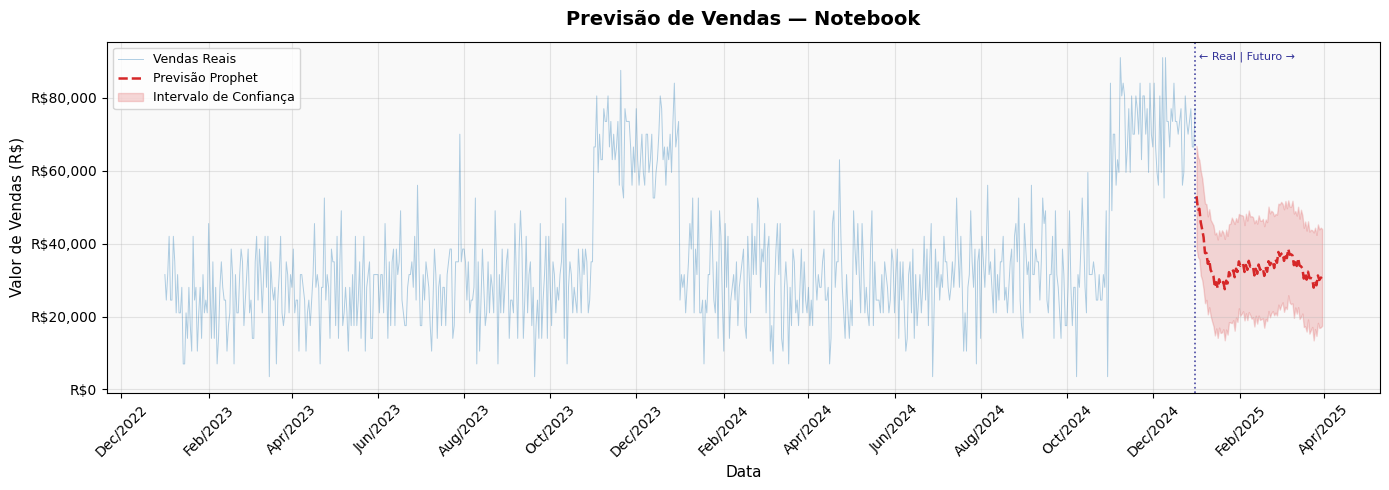

Previsão 90 dias — Notebook: R$ 3,052,457



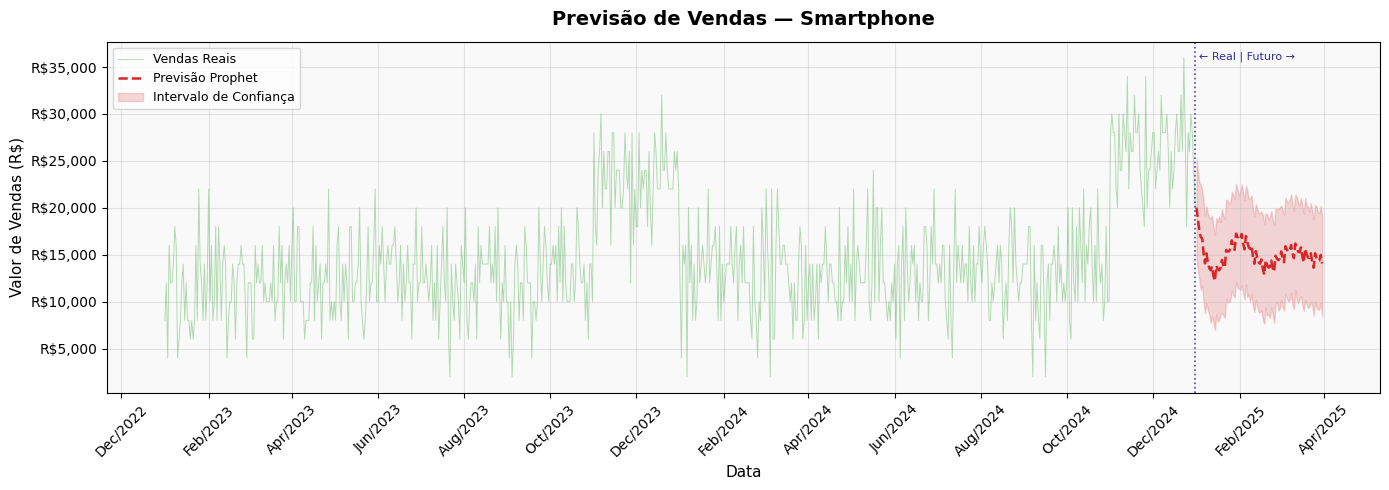

Previsão 90 dias — Smartphone: R$ 1,349,746



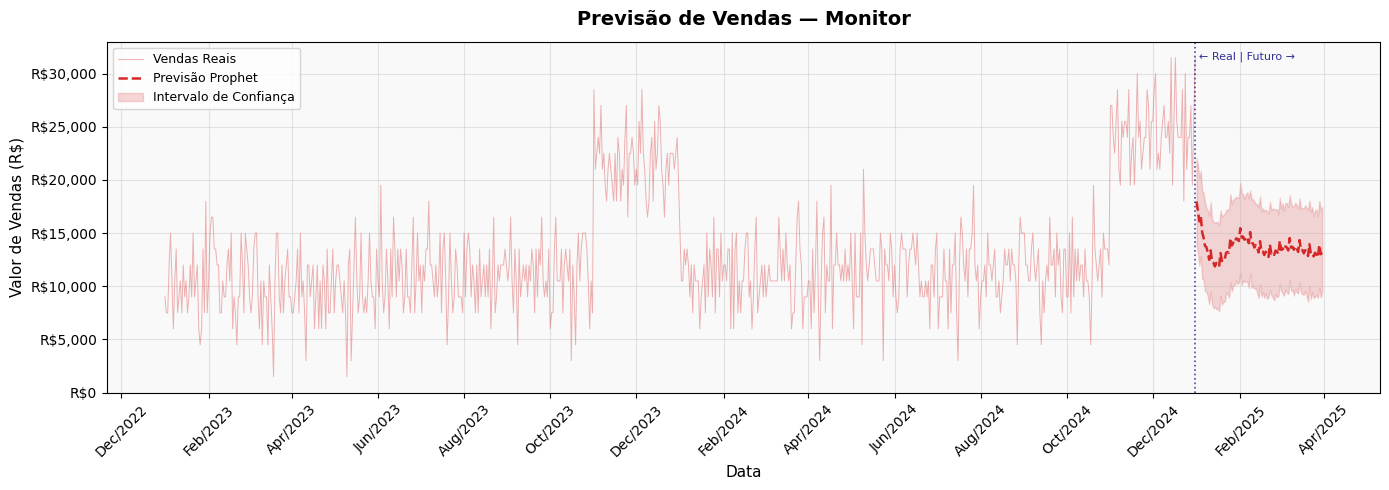

Previsão 90 dias — Monitor: R$ 1,228,149



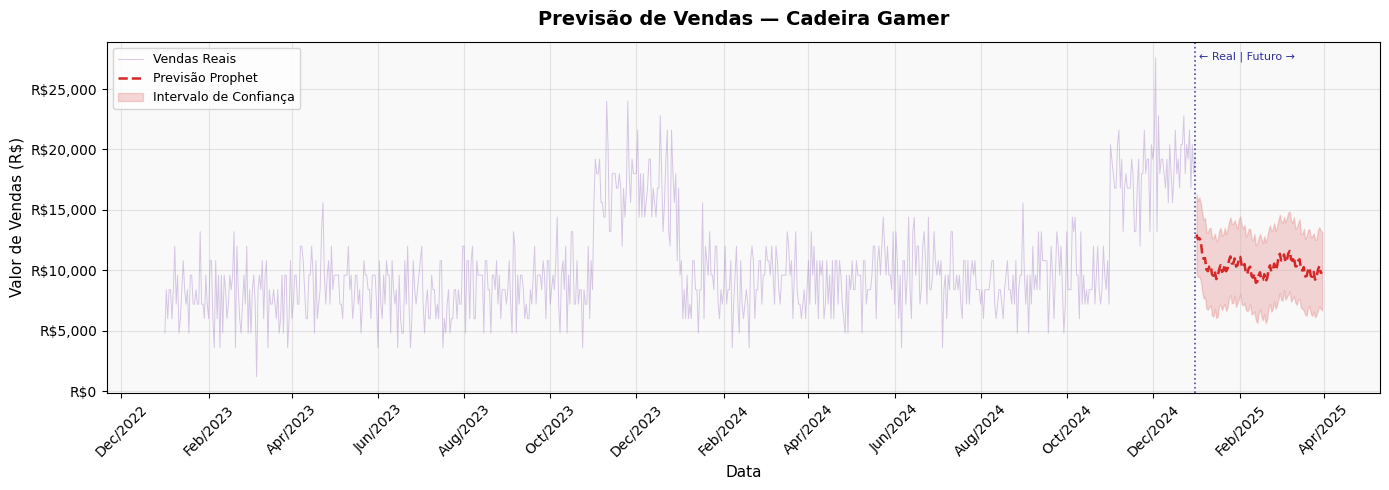

Previsão 90 dias — Cadeira Gamer: R$ 927,210



In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet
from datetime import timedelta

conn = criar_conexao()
cursor = conn.cursor()
cursor.execute("SELECT id, nome, preco_unit FROM produtos")
lista_produtos = cursor.fetchall()
fechar_conexao(conn)

CORES = {
    'Notebook':      '#1f77b4',
    'Smartphone':    '#2ca02c',
    'Monitor':       '#d62728',
    'Cadeira Gamer': '#9467bd',
}

for pid, nome, preco in lista_produtos:
    conn = criar_conexao()
    df = pd.read_sql(f"""
        SELECT data_venda AS ds, receita AS y
        FROM vendas WHERE produto_id = {pid}
        ORDER BY data_venda
    """, conn)
    fechar_conexao(conn)
    df['ds'] = pd.to_datetime(df['ds'])

    modelo = Prophet(interval_width=0.8, daily_seasonality=False,
                     weekly_seasonality=True, yearly_seasonality=True)
    modelo.fit(df)
    futuro   = modelo.make_future_dataframe(periods=90)
    forecast = modelo.predict(futuro)

    data_corte  = df['ds'].max()
    prev_futura = forecast[forecast['ds'] > data_corte]
    total_prev  = prev_futura['yhat'].sum()
    cor = CORES[nome]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df['ds'], df['y'], color=cor, alpha=0.35, linewidth=0.7, label='Vendas Reais')
    ax.plot(prev_futura['ds'], prev_futura['yhat'], '--', color='#d62728',
            linewidth=1.8, label='Previsão Prophet')
    ax.fill_between(prev_futura['ds'], prev_futura['yhat_lower'],
                    prev_futura['yhat_upper'], alpha=0.18, color='#d62728',
                    label='Intervalo de Confiança')
    ax.axvline(data_corte, color='navy', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(data_corte + timedelta(days=3), ax.get_ylim()[1]*0.95,
            '← Real | Futuro →', fontsize=8, color='navy', alpha=0.8)
    ax.set_title(f'Previsão de Vendas — {nome}', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Data', fontsize=11)
    ax.set_ylabel('Valor de Vendas (R$)', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'R${v:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.xticks(rotation=45)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f9f9f9')
    fig.tight_layout()
    plt.savefig(f'grafico_{nome.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Previsão 90 dias — {nome}: R$ {total_prev:,.0f}\n')

## Célula 4 — Relatório completo por produto

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


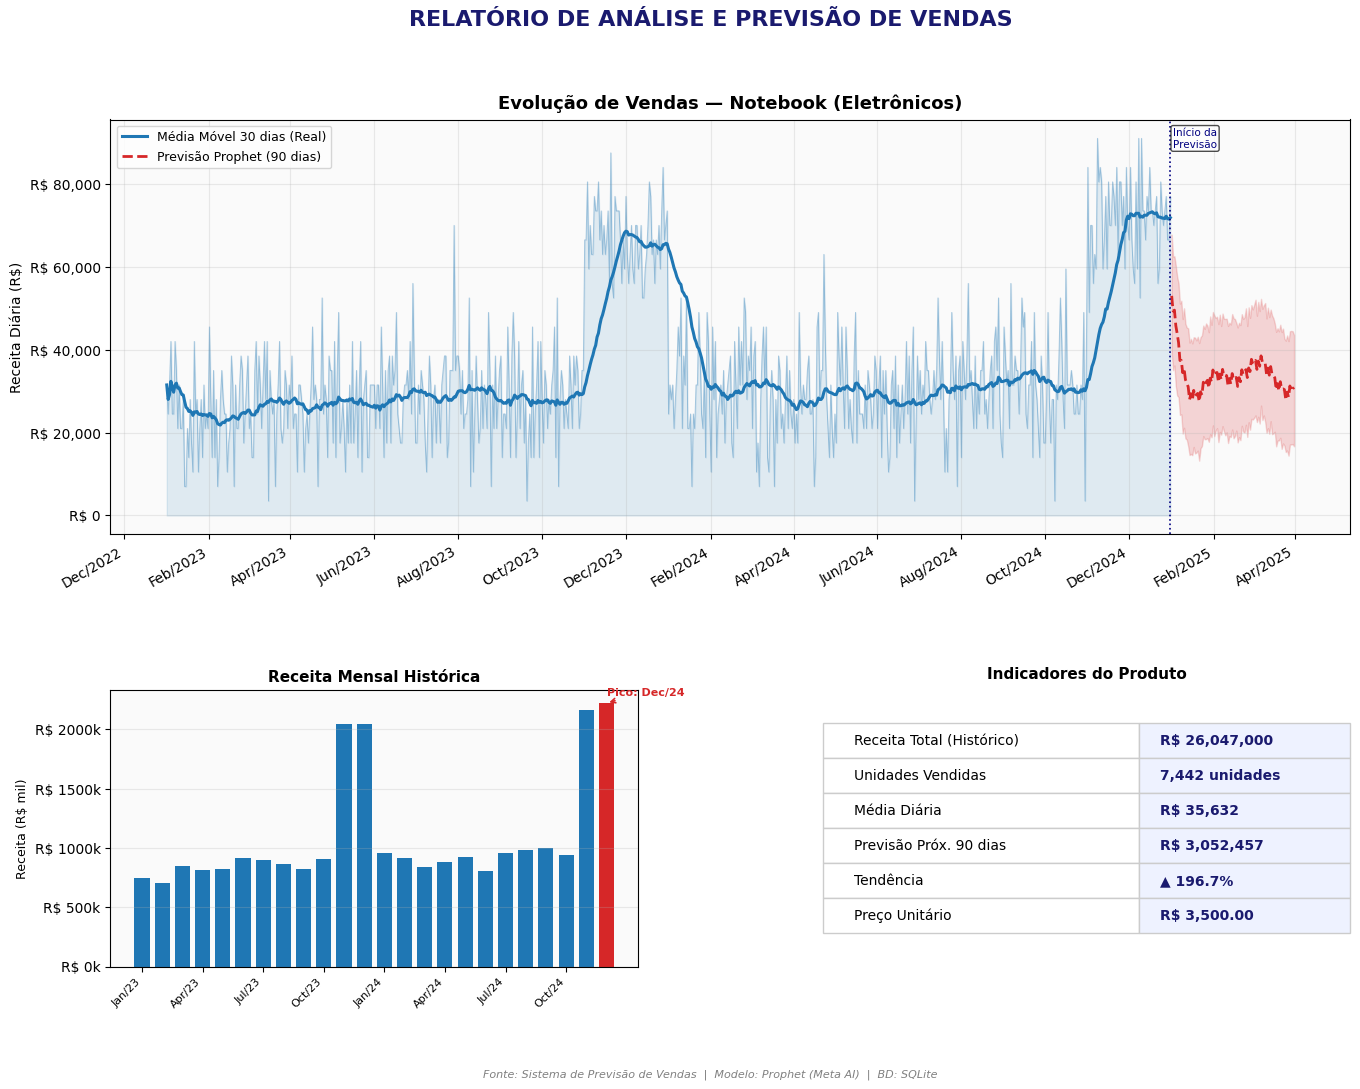

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Relatório gerado: Notebook


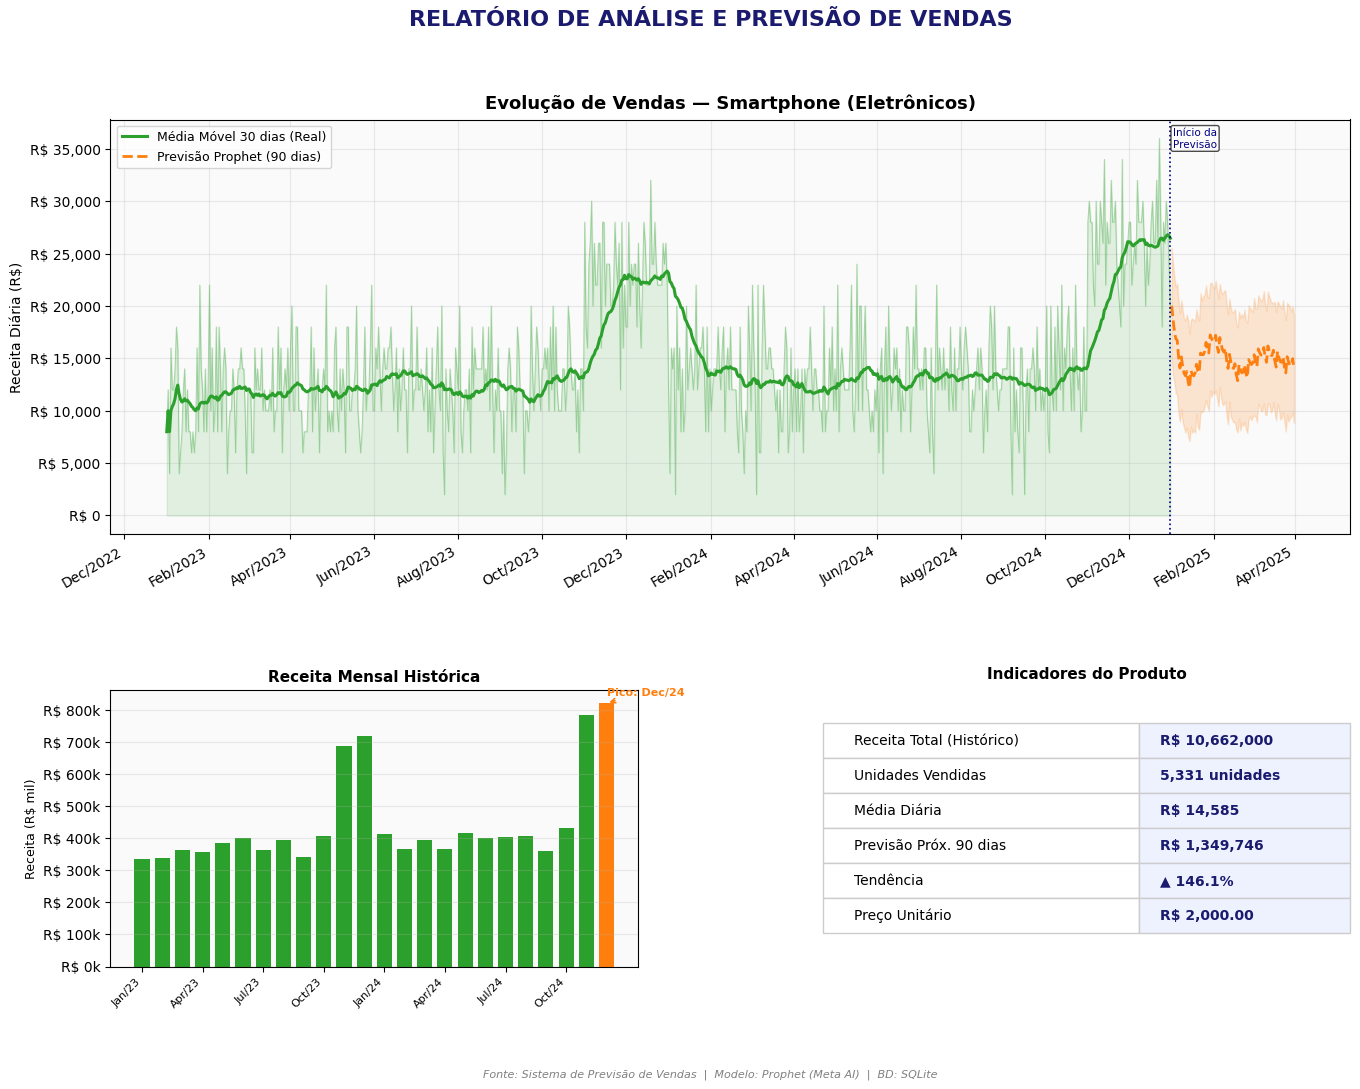

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Relatório gerado: Smartphone


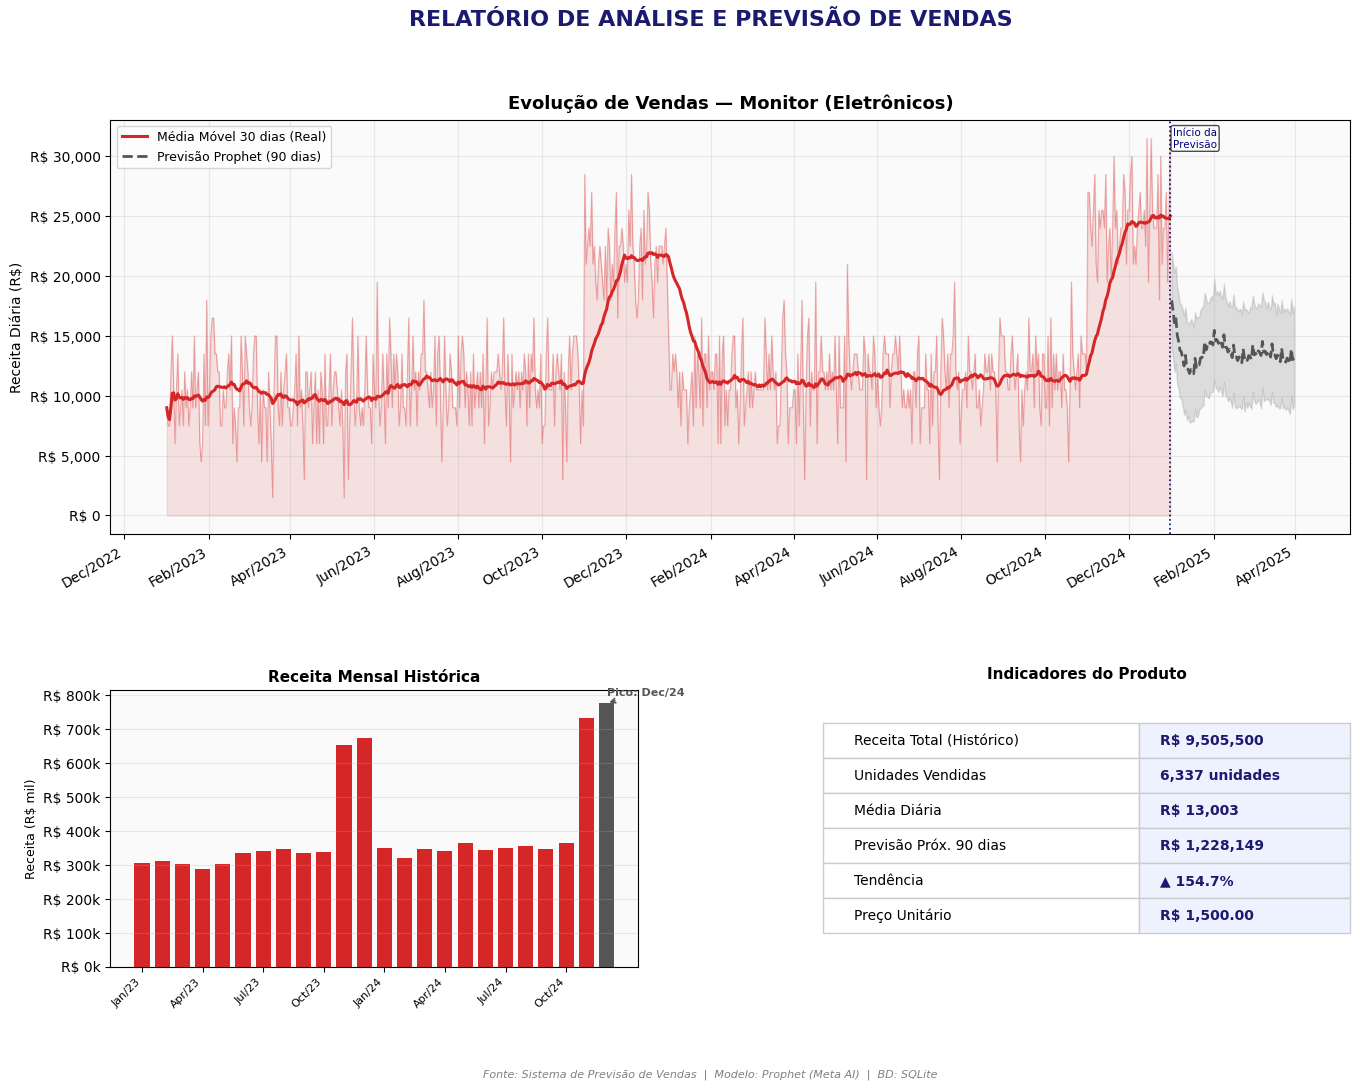

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Relatório gerado: Monitor


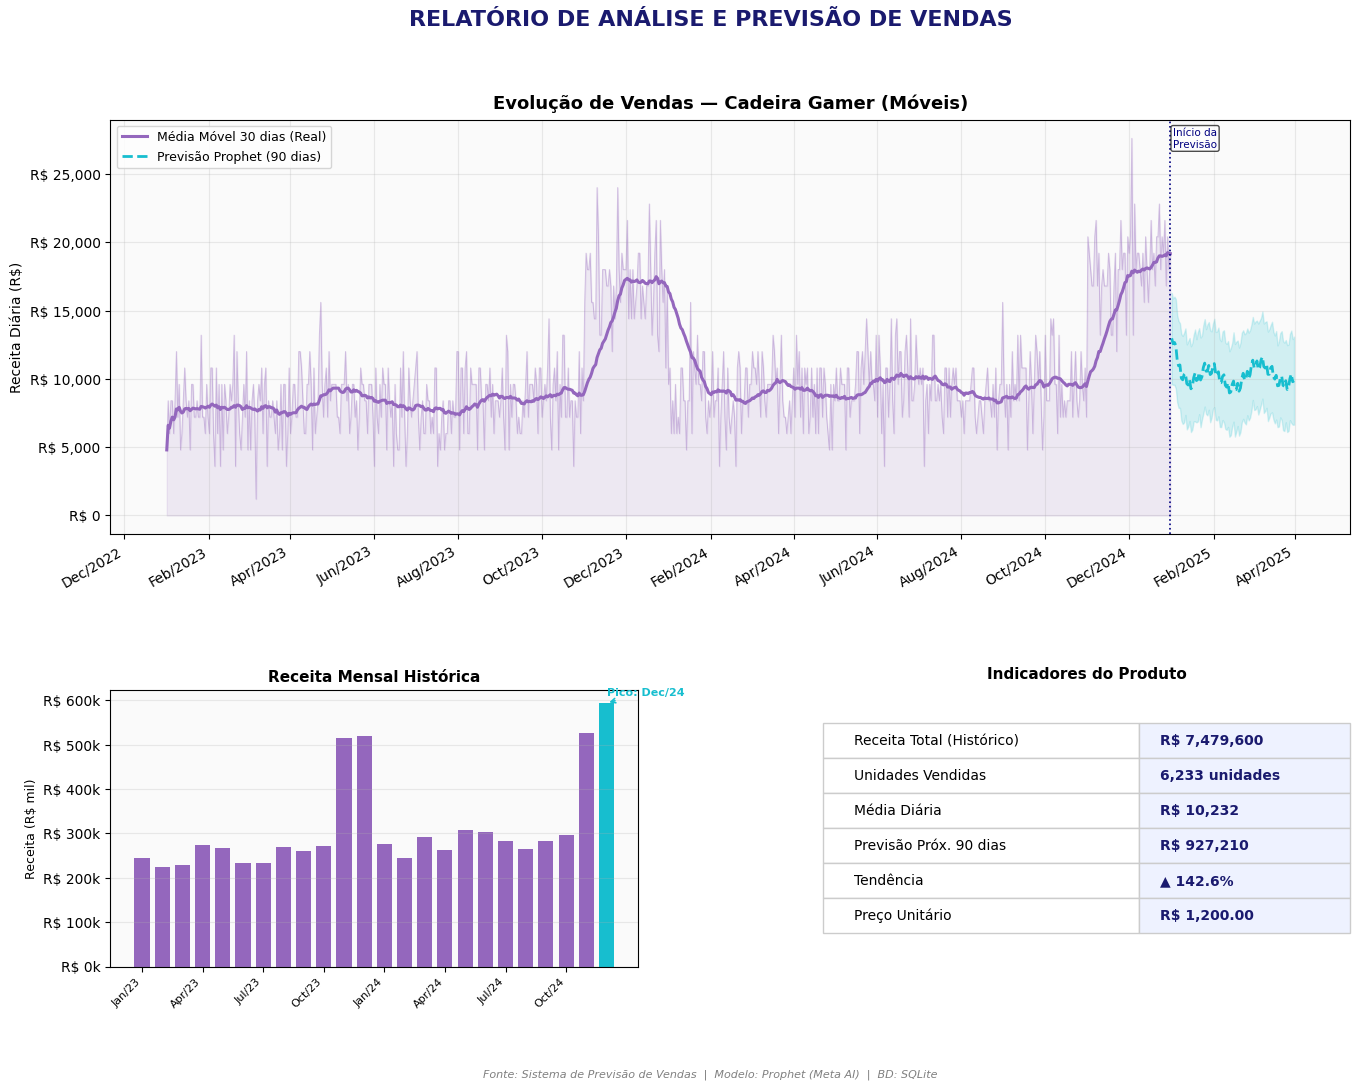

Relatório gerado: Cadeira Gamer


In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

conn = criar_conexao()
cursor = conn.cursor()
cursor.execute("""
    SELECT p.id, p.nome, p.preco_unit, c.nome AS categoria
    FROM produtos p JOIN categorias c ON c.id = p.categoria_id
""")
lista_produtos = cursor.fetchall()
fechar_conexao(conn)

CORES_REL = {
    'Notebook':      {'hist': '#1f77b4', 'prev': '#d62728'},
    'Smartphone':    {'hist': '#2ca02c', 'prev': '#ff7f0e'},
    'Monitor':       {'hist': '#d62728', 'prev': '#555555'},
    'Cadeira Gamer': {'hist': '#9467bd', 'prev': '#17becf'},
}

for pid, nome, preco, categoria in lista_produtos:
    conn = criar_conexao()
    df = pd.read_sql(f"""
        SELECT data_venda AS ds, receita AS y, quantidade
        FROM vendas WHERE produto_id = {pid} ORDER BY data_venda
    """, conn)
    fechar_conexao(conn)
    df['ds'] = pd.to_datetime(df['ds'])

    modelo = Prophet(interval_width=0.8, weekly_seasonality=True, yearly_seasonality=True)
    modelo.fit(df[['ds','y']])
    futuro   = modelo.make_future_dataframe(periods=90)
    forecast = modelo.predict(futuro)

    data_corte  = df['ds'].max()
    prev_futura = forecast[forecast['ds'] > data_corte]
    total_prev  = prev_futura['yhat'].sum()
    receita_total = df['y'].sum()
    unidades_tot  = df['quantidade'].sum()
    media_diaria  = df['y'].mean()

    df['mes'] = df['ds'].dt.to_period('M')
    mensal = df.groupby('mes')['y'].sum().reset_index()
    mensal['mes_str'] = mensal['mes'].astype(str)
    idx_pico  = mensal['y'].idxmax()
    pico_val  = mensal.loc[idx_pico, 'y']
    pico_label = pd.Period(mensal.loc[idx_pico, 'mes_str']).strftime('%b/%y')
    tendencia = ((mensal.iloc[-1]['y'] - mensal.iloc[0]['y']) / mensal.iloc[0]['y']) * 100
    df['mm30'] = df['y'].rolling(30, min_periods=1).mean()
    c = CORES_REL[nome]

    fig = plt.figure(figsize=(16, 11))
    fig.patch.set_facecolor('white')
    gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1.5,1], hspace=0.45, wspace=0.35)
    fig.suptitle('RELATÓRIO DE ANÁLISE E PREVISÃO DE VENDAS',
                 fontsize=16, fontweight='bold', color='#1a1a6e', y=0.98)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.fill_between(df['ds'], df['y'], alpha=0.12, color=c['hist'])
    ax1.plot(df['ds'], df['y'],   color=c['hist'], alpha=0.35, linewidth=0.7)
    ax1.plot(df['ds'], df['mm30'], color=c['hist'], linewidth=2.2,
             label='Média Móvel 30 dias (Real)')
    ax1.plot(prev_futura['ds'], prev_futura['yhat'], '--', color=c['prev'],
             linewidth=2.0, label='Previsão Prophet (90 dias)')
    ax1.fill_between(prev_futura['ds'], prev_futura['yhat_lower'],
                     prev_futura['yhat_upper'], alpha=0.18, color=c['prev'])
    ax1.axvline(data_corte, color='navy', linestyle=':', linewidth=1.2)
    ax1.text(data_corte + pd.Timedelta(days=2), ax1.get_ylim()[1]*0.93,
             'Início da\nPrevisão', fontsize=7.5, color='navy',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    ax1.set_title(f'Evolução de Vendas — {nome} ({categoria})',
                  fontsize=13, fontweight='bold', pad=8)
    ax1.set_ylabel('Receita Diária (R$)', fontsize=10)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.0f}'))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax1.legend(fontsize=9, loc='upper left')
    ax1.grid(True, alpha=0.25)
    ax1.set_facecolor('#fafafa')

    ax2 = fig.add_subplot(gs[1, 0])
    cores_bar = [c['prev'] if i == idx_pico else c['hist'] for i in mensal.index]
    ax2.bar(range(len(mensal)), mensal['y'], color=cores_bar, width=0.75, edgecolor='none')
    ax2.annotate(f'Pico: {pico_label}',
                 xy=(idx_pico, pico_val),
                 xytext=(min(idx_pico+1, len(mensal)-1), pico_val*1.03),
                 fontsize=8, color=c['prev'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=c['prev'], lw=1.2))
    xt = list(range(0, len(mensal), 3))
    xl = [pd.Period(mensal.iloc[i]['mes_str']).strftime('%b/%y') for i in xt]
    ax2.set_xticks(xt); ax2.set_xticklabels(xl, rotation=45, ha='right', fontsize=8)
    ax2.set_title('Receita Mensal Histórica', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Receita (R$ mil)', fontsize=9)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v/1000:.0f}k'))
    ax2.grid(True, axis='y', alpha=0.25)
    ax2.set_facecolor('#fafafa')

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')
    seta = '▼' if tendencia < 0 else '▲'
    indicadores = [
        ['Receita Total (Histórico)', f'R$ {receita_total:,.0f}'],
        ['Unidades Vendidas',         f'{int(unidades_tot):,} unidades'],
        ['Média Diária',              f'R$ {media_diaria:,.0f}'],
        ['Previsão Próx. 90 dias',    f'R$ {total_prev:,.0f}'],
        ['Tendência',                 f'{seta} {abs(tendencia):.1f}%'],
        ['Preço Unitário',            f'R$ {preco:,.2f}'],
    ]
    tab = ax3.table(cellText=indicadores, colWidths=[0.6,0.4], loc='center', cellLoc='left')
    tab.auto_set_font_size(False)
    tab.set_fontsize(10)
    tab.scale(1, 2.1)
    for (r, col), cell in tab.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if col == 1:
            cell.set_text_props(fontweight='bold', color='#1a1a6e')
            cell.set_facecolor('#eef2ff')
        else:
            cell.set_facecolor('#ffffff')
    ax3.set_title('Indicadores do Produto', fontsize=11, fontweight='bold', pad=8)

    fig.text(0.5, 0.01,
             'Fonte: Sistema de Previsão de Vendas  |  Modelo: Prophet (Meta AI)  |  BD: SQLite',
             ha='center', fontsize=8, color='gray', style='italic')
    plt.savefig(f'relatorio_{nome.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Relatório gerado: {nome}')

## Célula 5 — Dashboard completo (4 produtos)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Notebook processado


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Smartphone processado


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Monitor processado
Cadeira Gamer processado


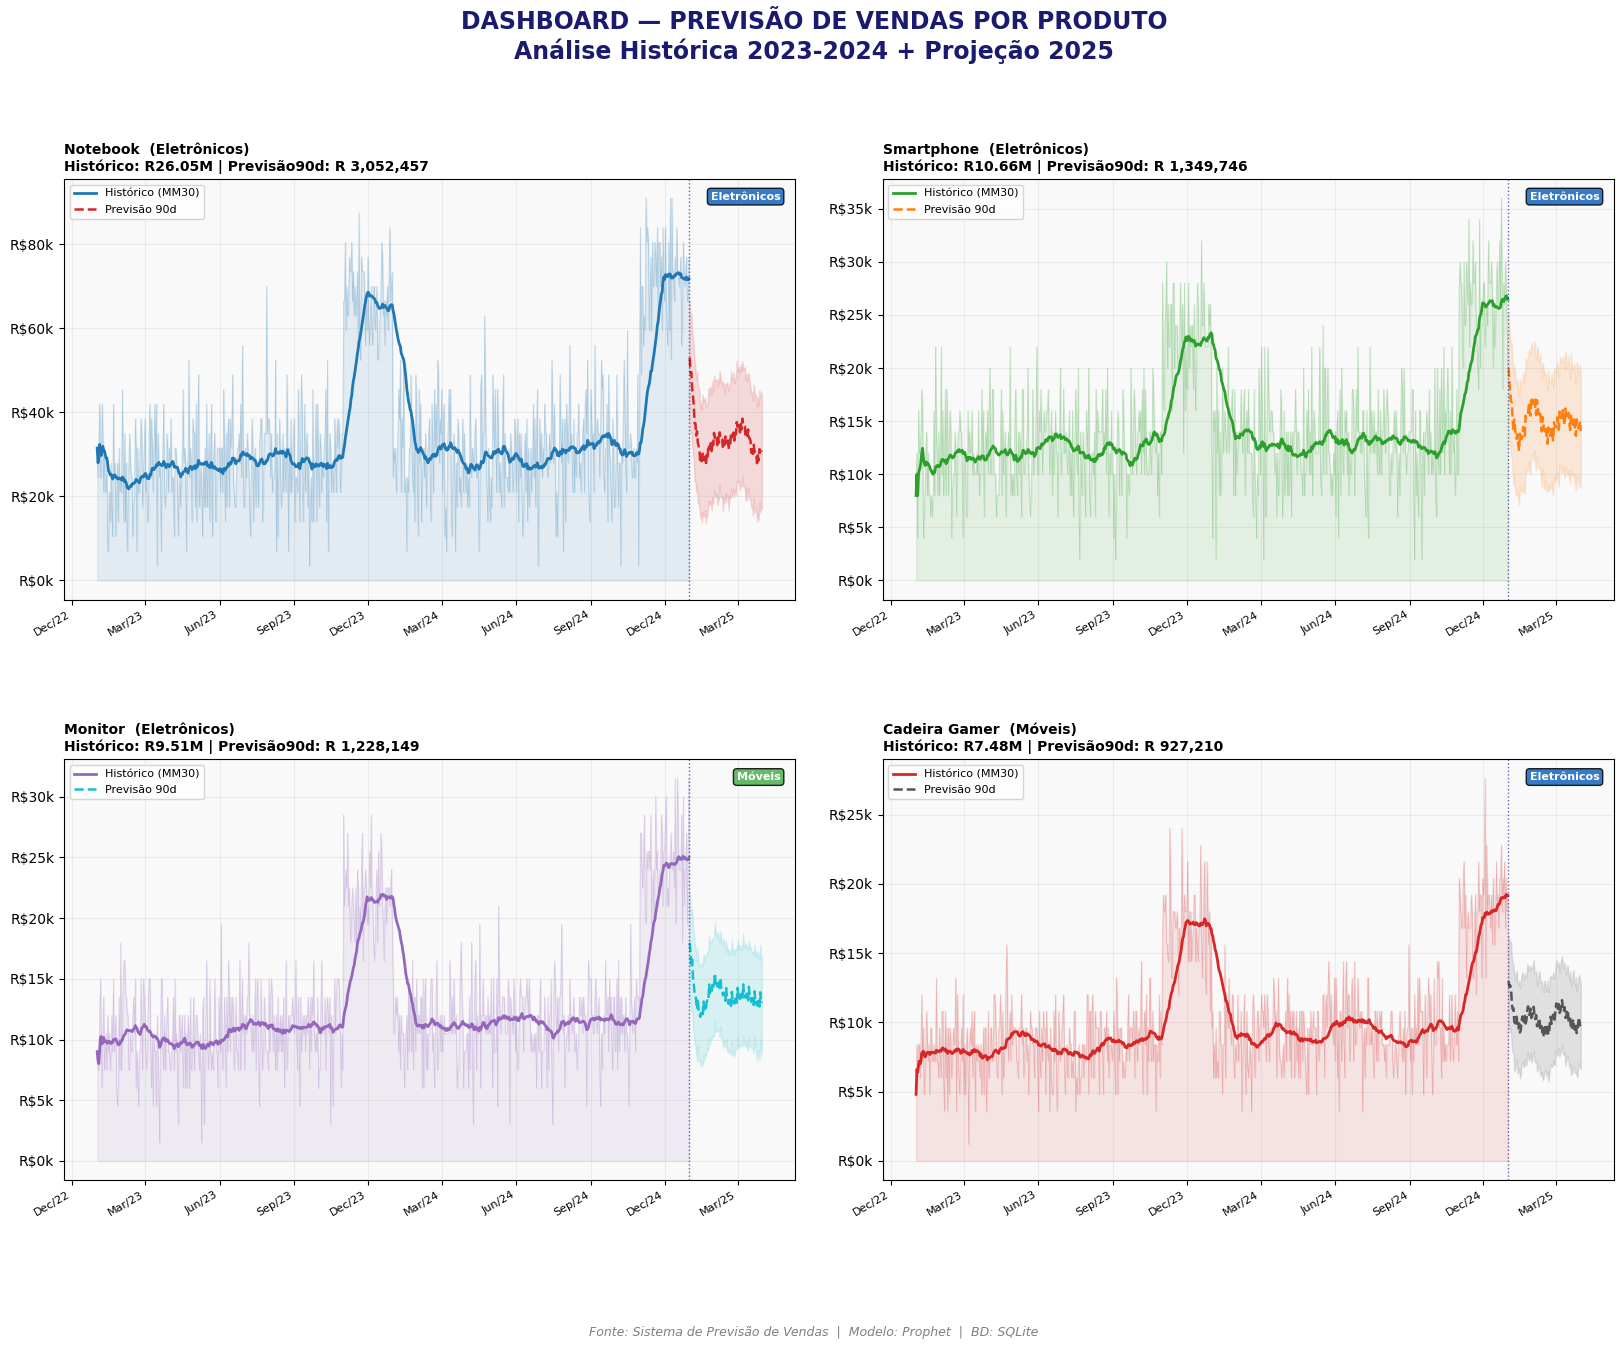


 Dashboard salvo: dashboard_completo.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

conn = criar_conexao()
cursor = conn.cursor()
cursor.execute("""
    SELECT p.id, p.nome, p.preco_unit, c.nome
    FROM produtos p JOIN categorias c ON c.id = p.categoria_id ORDER BY p.id
""")
lista_produtos = cursor.fetchall()
fechar_conexao(conn)

CORES_DASH = [
    {'hist': '#1f77b4', 'prev': '#d62728', 'label': 'Eletrônicos', 'bg': '#1565C0'},
    {'hist': '#2ca02c', 'prev': '#ff7f0e', 'label': 'Eletrônicos', 'bg': '#1565C0'},
    {'hist': '#9467bd', 'prev': '#17becf', 'label': 'Móveis',      'bg': '#4CAF50'},
    {'hist': '#d62728', 'prev': '#555555', 'label': 'Eletrônicos', 'bg': '#1565C0'},
]

fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor('white')
fig.suptitle('DASHBOARD — PREVISÃO DE VENDAS POR PRODUTO\nAnálise Histórica 2023-2024 + Projeção 2025',
             fontsize=17, fontweight='bold', color='#1a1a6e', y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.12)

for idx, (pid, nome, preco, categoria) in enumerate(lista_produtos):
    conn = criar_conexao()
    df = pd.read_sql(f"""
        SELECT data_venda AS ds, receita AS y
        FROM vendas WHERE produto_id = {pid} ORDER BY data_venda
    """, conn)
    fechar_conexao(conn)
    df['ds'] = pd.to_datetime(df['ds'])

    modelo = Prophet(interval_width=0.8, weekly_seasonality=True, yearly_seasonality=True)
    modelo.fit(df[['ds','y']])
    futuro   = modelo.make_future_dataframe(periods=90)
    forecast = modelo.predict(futuro)

    data_corte  = df['ds'].max()
    prev_futura = forecast[forecast['ds'] > data_corte]
    total_hist  = df['y'].sum()
    total_prev  = prev_futura['yhat'].sum()
    df['mm30']  = df['y'].rolling(30, min_periods=1).mean()

    c   = CORES_DASH[idx]
    ax  = fig.add_subplot(gs[idx // 2, idx % 2])

    ax.fill_between(df['ds'], df['y'], alpha=0.1, color=c['hist'])
    ax.plot(df['ds'], df['y'],   color=c['hist'], alpha=0.25, linewidth=0.5)
    ax.plot(df['ds'], df['mm30'], color=c['hist'], linewidth=2.0, label='Histórico (MM30)')
    ax.plot(prev_futura['ds'], prev_futura['yhat'], '--', color=c['prev'],
            linewidth=1.8, label='Previsão 90d')
    ax.fill_between(prev_futura['ds'], prev_futura['yhat_lower'],
                    prev_futura['yhat_upper'], alpha=0.15, color=c['prev'])
    ax.axvline(data_corte, color='navy', linestyle=':', linewidth=1.0, alpha=0.6)

    ax.text(0.98, 0.97, c['label'], transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=c['bg'], alpha=0.85))

    hist_fmt = f'R{total_hist/1e6:.2f}M' if total_hist >= 1e6 else f'R{total_hist/1e3:.0f}k'
    ax.set_title(f'{nome}  ({categoria})\nHistórico: {hist_fmt} | Previsão90d: R {total_prev:,.0f}',
                 fontsize=10, fontweight='bold', loc='left', pad=6)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1000:.0f}k'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.2)
    ax.set_facecolor('#f9f9f9')
    print(f'{nome} processado')

fig.text(0.5, -0.01,
         'Fonte: Sistema de Previsão de Vendas  |  Modelo: Prophet  |  BD: SQLite',
         ha='center', fontsize=9, color='gray', style='italic')
plt.savefig('dashboard_completo.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Dashboard salvo: dashboard_completo.png')

## Célula 6 — Tabela resumo final

In [6]:
conn = criar_conexao()
df_resumo = pd.read_sql("""
    SELECT
        p.nome                     AS Produto,
        c.nome                     AS Categoria,
        p.preco_unit               AS "Preco Unit",
        COUNT(v.id)                AS "Dias com Venda",
        SUM(v.quantidade)          AS "Unidades Vendidas",
        ROUND(SUM(v.receita), 0)   AS "Receita Total",
        ROUND(AVG(v.receita), 0)   AS "Media Diaria"
    FROM vendas v
    JOIN produtos p  ON p.id = v.produto_id
    JOIN categorias c ON c.id = p.categoria_id
    GROUP BY p.id
    ORDER BY SUM(v.receita) DESC
""", conn)
fechar_conexao(conn)

for col in ['Preco Unit', 'Receita Total', 'Media Diaria']:
    df_resumo[col] = df_resumo[col].map('R$ {:,.0f}'.format)

print('='*70)
print('  RESUMO GERAL — SISTEMA DE PREVISÃO DE VENDAS')
print('='*70)
print(df_resumo.to_string(index=False))
print('='*70)
print()
print('Projeto executado com sucesso!')
print('Arquivos gerados: dashboard_completo.png + relatórios individuais')

  RESUMO GERAL — SISTEMA DE PREVISÃO DE VENDAS
      Produto   Categoria Preco Unit  Dias com Venda  Unidades Vendidas Receita Total Media Diaria
     Notebook Eletrônicos   R$ 3,500             731               7442 R$ 26,047,000    R$ 35,632
   Smartphone Eletrônicos   R$ 2,000             731               5331 R$ 10,662,000    R$ 14,585
      Monitor Eletrônicos   R$ 1,500             731               6337  R$ 9,505,500    R$ 13,003
Cadeira Gamer      Móveis   R$ 1,200             731               6233  R$ 7,479,600    R$ 10,232

Projeto executado com sucesso!
Arquivos gerados: dashboard_completo.png + relatórios individuais
